# 04 — Training and Representation Learning (PyTorch)

We train the shared 784 → 64 → 10 classifier, then a 784 → 2 → 10 bottleneck network to make representation learning geometrically visible.


## Why this notebook matters: training is geometry changing over time

A neural network does not merely memorize a better answer after every optimizer step. Its **internal coordinate system changes**. The same MNIST image is repeatedly mapped through the network, but the hidden coordinates produced by the learned weights and biases move as training proceeds.

For a hidden layer,

$$
\mathbf{h}=\phi(W\mathbf{x}+\mathbf{b})
$$

so changing $W$ or $\mathbf{b}$ changes the coordinates $\mathbf{h}$ assigned to the same input image $\mathbf{x}$. This is the concrete meaning of **representation learning**.

### The complete causal loop

1. A 28×28 digit becomes a 784-dimensional input vector $\mathbf{x}$.
2. Forward propagation computes hidden coordinates and class logits.
3. The loss measures how incompatible those logits are with the true digit label.
4. Backpropagation computes how each parameter contributed to that error.
5. The optimizer updates parameters in the direction that should reduce future loss.
6. On the next forward pass, the same digit lands at a slightly different hidden representation.
7. Repeating this process can make digits of the same class form more coherent regions while separating confusing classes.

The update is conceptually

$$
\theta_{t+1}=\theta_t-\eta\nabla_{\theta}\mathcal{L}(\theta_t),
$$

where $\theta$ represents all weights and biases and $\eta$ is the learning rate. Because the representation itself depends on $\theta$, every update can reshape the geometry seen by later layers.

### What controls the learned geometry?

| Factor | What changes | What you may observe |
| --- | --- | --- |
| Initialization | Starting orientation and scale of the feature space | Different early trajectories and convergence speed |
| Learning rate | Size of each parameter update | Smooth progress, oscillation, or divergence |
| Activation | Which affine responses survive or saturate | Sparse, clipped, curved, or saturated representations |
| Hidden width | Capacity of the intermediate representation | Underfitting vs richer separability |
| Loss function | What errors are penalized | Different class margins and confidence behaviour |
| Optimizer | How gradient history is converted into updates | Different paths through parameter space |
| Regularization | Preference for simpler parameter configurations | Better generalization or reduced overfitting |

### How to read the visualizations in this notebook

Do not look only at the final accuracy. Follow one sample conceptually through time. At epoch 0 its hidden coordinate may be close to several competing classes. After many gradient updates, that same sample may move into a region where the output layer can separate it with a much simpler boundary. The model has therefore made the downstream classification problem easier by learning a better representation.

A useful mental model is:

$$
\text{pixels} \rightarrow \text{learned coordinates} \rightarrow \text{class evidence} \rightarrow \text{loss}
$$

and during training the information flows backward:

$$
\text{loss} \rightarrow \text{gradients} \rightarrow \text{parameter updates} \rightarrow \text{new coordinates}.
$$

### Engineering interpretation

Training curves alone are insufficient for debugging. Two runs can have similar loss while learning very different internal geometries. In production work, inspect several signals together: training/test loss, class-wise accuracy, confusion matrices, confidence distributions, gradient magnitude, and representative hidden embeddings. If the loss falls but test geometry remains poorly separated, the model may be fitting shortcuts rather than learning transferable structure.

### Business interpretation

For MNIST the customer is simply the downstream digit classifier, but the same mechanism appears in enterprise systems. A representation layer can turn raw events, documents, images, transactions, or customer attributes into coordinates where fraud, intent, defect type, risk category, or product class becomes easier to separate. The commercial value of a deep model often comes from this learned representation rather than from the final linear decision layer alone.

### Final checkpoint

After this notebook you should be able to explain the full causal chain without framework terminology:

**input → weighted transformations → hidden representation → prediction → loss → gradient → parameter update → changed representation.**

That chain is the core mechanism behind learning in every ANN implementation in this repository, whether the arithmetic is written manually, delegated to PyTorch autograd, or delegated to TensorFlow GradientTape.


train (5000, 784) test (1000, 784)


1 2.3038177490234375 0.12219999730587006
2 2.2642533779144287 0.19699999690055847
3 2.2248668670654297 0.27239999175071716
4 2.1816415786743164 0.3537999987602234
5 2.133779525756836 0.4311999976634979
6 2.0810909271240234 0.49559998512268066
7 2.0234534740448 0.5501999855041504
8 1.9612587690353394 0.5938000082969666
test accuracy 0.6019999980926514


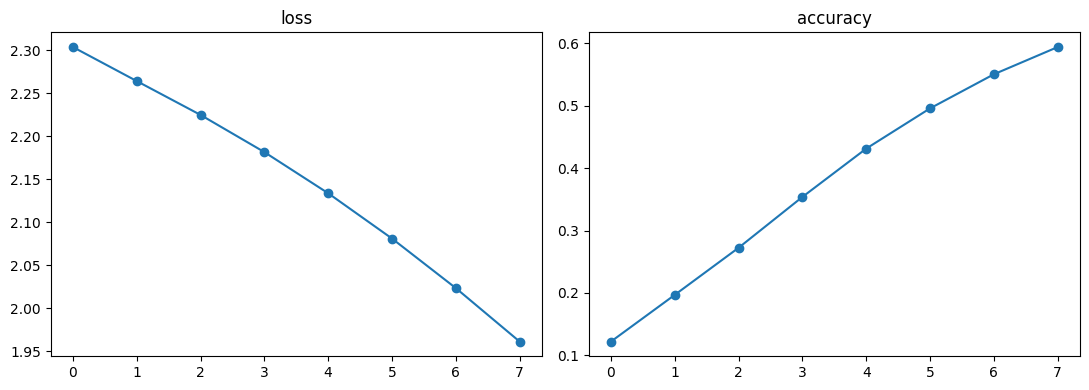

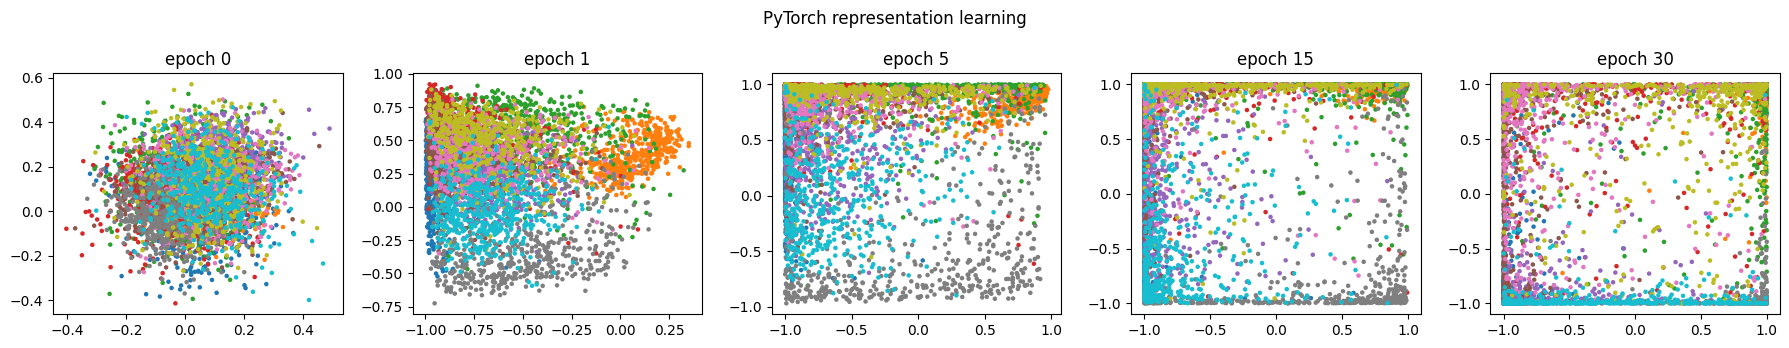

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import torch,torch.nn as nn,matplotlib.pyplot as plt
torch.manual_seed(42);X=torch.tensor(x_train);Y=torch.tensor(y_train,dtype=torch.long);Xt=torch.tensor(x_test);Yt=torch.tensor(y_test,dtype=torch.long);model=nn.Sequential(nn.Linear(784,64),nn.ReLU(),nn.Linear(64,10));opt=torch.optim.SGD(model.parameters(),lr=.25);crit=nn.CrossEntropyLoss();losses=[];accs=[]
for ep in range(8):opt.zero_grad();q=model(X);loss=crit(q,Y);loss.backward();opt.step();acc=(q.argmax(1)==Y).float().mean().item();losses.append(loss.item());accs.append(acc);print(ep+1,loss.item(),acc)
with torch.no_grad():print('test accuracy',(model(Xt).argmax(1)==Yt).float().mean().item())
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].plot(losses,marker='o');axes[1].plot(accs,marker='o');axes[0].set_title('loss');axes[1].set_title('accuracy');plt.tight_layout();plt.show()
class B(nn.Module):
 def __init__(self):super().__init__();self.e=nn.Linear(784,2);self.o=nn.Linear(2,10)
 def forward(self,x):h=torch.tanh(self.e(x));return self.o(h),h
torch.manual_seed(7);b=B();opt=torch.optim.SGD(b.parameters(),lr=.7);snaps={}
for ep in range(31):opt.zero_grad();q,h=b(X);loss=crit(q,Y);snaps[ep]=h.detach().numpy().copy() if ep in [0,1,5,15,30] else snaps.get(ep);loss.backward();opt.step()
fig,axes=plt.subplots(1,5,figsize=(18,3.5))
for ax,ep in zip(axes,[0,1,5,15,30]):H=snaps[ep];ax.scatter(H[:,0],H[:,1],c=y_train,s=5,cmap='tab10');ax.set_title(f'epoch {ep}')
plt.suptitle('PyTorch representation learning');plt.tight_layout();plt.show()


## What “representation learning” actually means
The same MNIST images receive different hidden coordinates after parameter updates. Training is therefore not merely reducing a number called loss; it is **reorganizing data geometry** so the output layer can separate classes more easily.
